In [1]:
import os

# Disable PIR + oneDNN/MKLDNN to avoid the known CPU inference issue
os.environ["FLAGS_enable_pir_api"] = "0"
os.environ["FLAGS_use_mkldnn"] = "0"
os.environ["PADDLE_PDX_ENABLE_MKLDNN_BYDEFAULT"] = "0"

from paddleocr import LayoutDetection

model = LayoutDetection(
    model_name="PP-DocLayout_plus-L"
)

print("Layout model loaded successfully!")

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-DocLayout_plus-L`.


Layout model loaded successfully!


In [1]:
import paddle

print(paddle.__version__)
print(paddle.get_device())

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


3.3.1
cpu


In [2]:
from paddleocr import LayoutDetection

model = LayoutDetection(
    model_name="PP-DocLayout_plus-L"
)

print("Model loaded successfully!")

Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-DocLayout_plus-L`.


Model loaded successfully!


In [22]:

# ============================================================
# 2. Upload an image
# ============================================================

from google.colab import files

uploaded = files.upload()

image_path = next(iter(uploaded.keys()))

print(f"Image: {image_path}")


# ============================================================
# 3. Load Layout Detection model ONLY
# ============================================================

from paddleocr import LayoutDetection

model = LayoutDetection(
    model_name="PP-DocLayout_plus-L",
    threshold=0.25,
    layout_nms=False
)


# ============================================================
# 4. Run layout detection
# ============================================================

output = model.predict(
    "page_0004.png",
    batch_size=1
)


# ============================================================
# 5. Print JSON result
# ============================================================

for res in output:
    res.print()
    res.save_to_img(
        save_path="./layout_test/"
    )
    res.save_to_json(
        save_path="./layout_test/result.json"
    )

print("\nDone!")
print("JSON: ./layout_result.json")
print("Visualization: ./layout_visualization/")

Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-DocLayout_plus-L`.


Saving page_0004_05_binary.png to page_0004_05_binary (6).png
Image: page_0004_05_binary (6).png


{'res': {'input_path': 'page_0004.png', 'page_index': None, 'boxes': [{'cls_id': 2, 'label': 'text', 'score': 0.937690794467926, 'coordinate': [np.float32(446.5812), np.float32(1703.3431), np.float32(1652.813), np.float32(1833.2347)]}, {'cls_id': 2, 'label': 'text', 'score': 0.9340755343437195, 'coordinate': [np.float32(440.35577), np.float32(1053.3916), np.float32(1647.6945), np.float32(1253.281)]}, {'cls_id': 2, 'label': 'text', 'score': 0.8955280184745789, 'coordinate': [np.float32(450.23047), np.float32(1945.8422), np.float32(1646.266), np.float32(2151.2869)]}, {'cls_id': 2, 'label': 'text', 'score': 0.8572065830230713, 'coordinate': [np.float32(443.0817), np.float32(1378.1327), np.float32(1643.8387), np.float32(1579.9198)]}, {'cls_id': 0, 'label': 'paragraph_title', 'score': 0.7348447442054749, 'coordinate': [np.float32(975.00433), np.float32(1298.7622), np.float32(1114.7241), np.float32(1339.1984)]}, {'cls_id': 3, 'label': 'number', 'score': 0.7331411242485046, 'coordinate': [np.

KeyError: 'res'

['./layout_visualization/page_0004_05_binary_res.png', './layout_visualization/page_0004 (3)_res.png', './layout_visualization/page_0004_05_binary (1)_res.png']


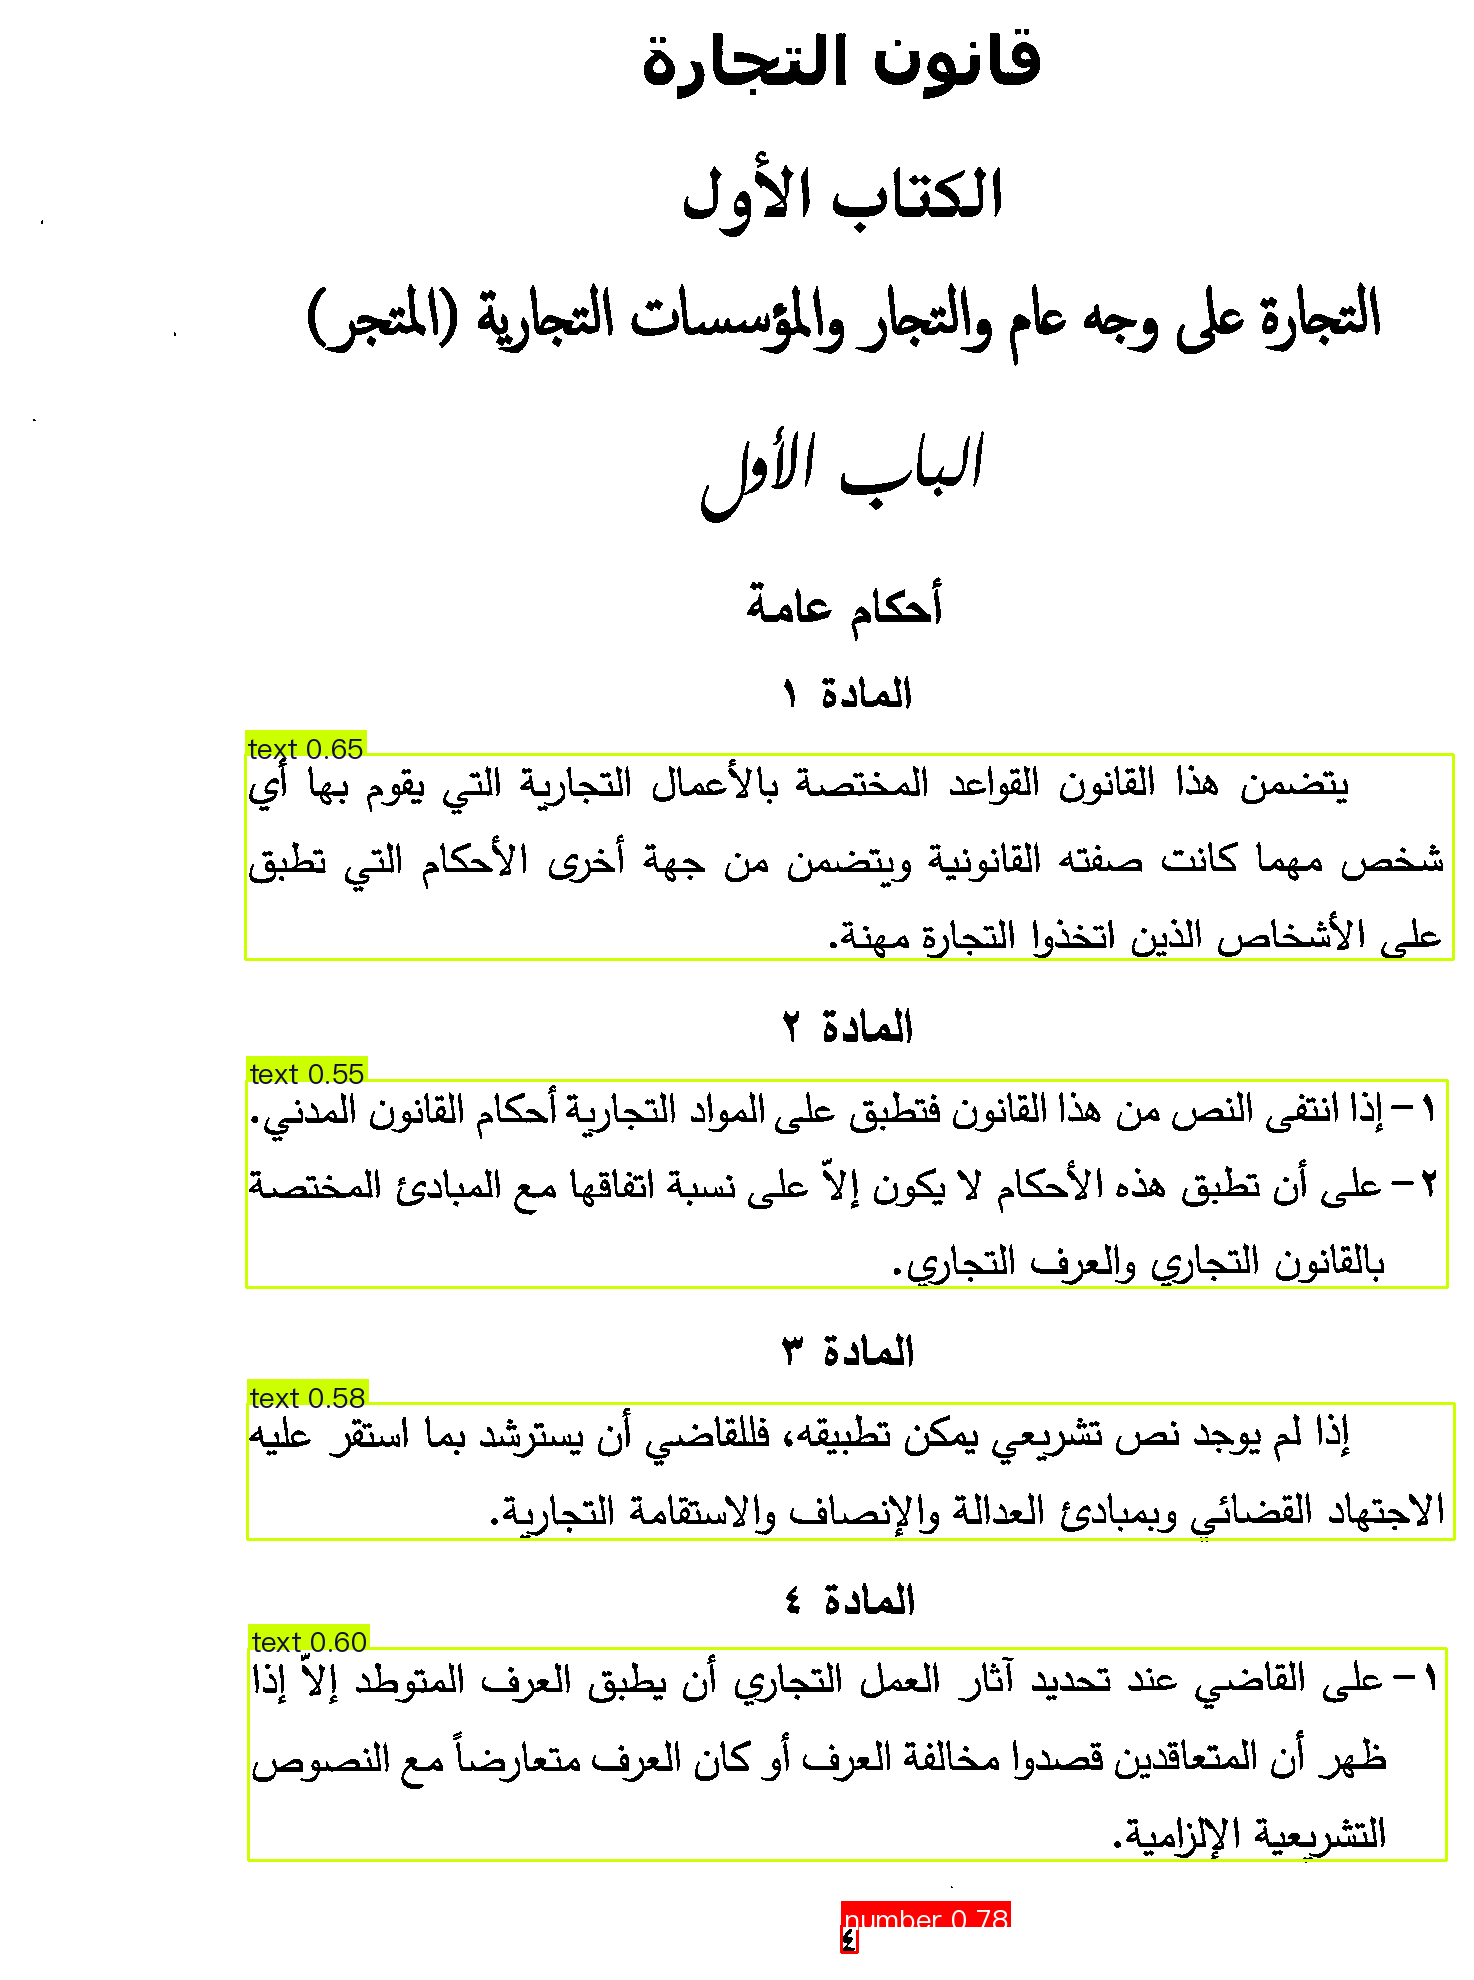

In [19]:
from IPython.display import Image, display
import glob

files = glob.glob("./layout_visualization/*")

print(files)

display(Image(filename=files[0]))

In [20]:
import json

with open("./layout_result.json", "r", encoding="utf-8") as f:
    data = json.load(f)

print(json.dumps(data, indent=2, ensure_ascii=False))

{
  "input_path": "page_0004_05_binary (1).png",
  "page_index": null,
  "boxes": [
    {
      "cls_id": 3,
      "label": "number",
      "score": 0.7779861092567444,
      "coordinate": [
        841.8544311523438,
        1925.6915283203125,
        857.0186157226562,
        1952.6690673828125
      ]
    },
    {
      "cls_id": 2,
      "label": "text",
      "score": 0.6519873142242432,
      "coordinate": [
        245.43309020996094,
        754.7979736328125,
        1453.4215087890625,
        959.80615234375
      ]
    },
    {
      "cls_id": 2,
      "label": "text",
      "score": 0.5981196761131287,
      "coordinate": [
        248.91152954101562,
        1648.3609619140625,
        1446.9937744140625,
        1860.8798828125
      ]
    },
    {
      "cls_id": 2,
      "label": "text",
      "score": 0.5770524740219116,
      "coordinate": [
        247.11270141601562,
        1403.6302490234375,
        1454.2022705078125,
        1539.2930908203125
      ]
    },

In [24]:
for i, res in enumerate(output):
    print("TYPE:", type(res))
    print("DIR:", [x for x in dir(res) if not x.startswith("_")][:50])
    print("RES:")
    print(res)
    print("-" * 80)

TYPE: <class 'paddlex.inference.models.object_detection.result.DetResult'>
DIR: ['clear', 'copy', 'fromkeys', 'get', 'img', 'items', 'json', 'keys', 'pop', 'popitem', 'print', 'save_all', 'save_to_img', 'save_to_json', 'setdefault', 'str', 'update', 'values']
RES:
{'input_path': 'page_0004.png', 'page_index': None, 'input_img': array([[[255, ..., 255],
        ...,
        [255, ..., 255]],

       ...,

       [[255, ..., 255],
        ...,
        [255, ..., 255]]], dtype=uint8), 'boxes': [{'cls_id': 2, 'label': 'text', 'score': 0.937690794467926, 'coordinate': [np.float32(446.5812), np.float32(1703.3431), np.float32(1652.813), np.float32(1833.2347)]}, {'cls_id': 2, 'label': 'text', 'score': 0.9340755343437195, 'coordinate': [np.float32(440.35577), np.float32(1053.3916), np.float32(1647.6945), np.float32(1253.281)]}, {'cls_id': 2, 'label': 'text', 'score': 0.8955280184745789, 'coordinate': [np.float32(450.23047), np.float32(1945.8422), np.float32(1646.266), np.float32(2151.2869)]}, {